# Plotting Composite Kernel Components

The [Composite Kernels](composite_kernels.ipynb) tutorial shows how to
**build** an additive kernel

$$K_{\rm total}(\tau) = \sum_m K_m(\tau;\,\theta_m)$$

out of several `Term`s (spot populations, an SHO granulation floor, jitter,
...). This tutorial is about **visualizing** that decomposition, using
three purpose-built pieces of API:

- **`KernelSum.components(theta, lag, drop_dc=False)`** — evaluates every
  term individually at a shared theta, correctly sliced from the full
  parameter vector (not each term's own stored initial value), plus a
  trailing `"Total"` entry.
- **`Term.k_of_lag_no_dc`** (used internally by `components` when
  `drop_dc=True`) — the kernel with the $n=0$ (non-oscillating) harmonic
  excluded from every spot term. Useful when comparing against an
  empirical ACF whose own DC power has been suppressed by mean
  subtraction or detrending.
- **`GPSolver.plot_acf` / `plot_psd`** with `components=True` — canned
  overlays built on `components()`, plus **`GPSolver.predict_at`** for
  predicting at an arbitrary theta, which composite kernels otherwise
  can't do (`update_hparam` raises for them).

We'll look at three things in turn: **1)** sampled lightcurves decomposed
by component, **2)** the kernel/ACF, and **3)** the PSD.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from spotgp import GPSolver, KernelSum, SpotTerm, SHOTerm

rng = np.random.default_rng(42)

# Colorblind-safe component colors (Okabe-Ito), matching composite_kernels.ipynb
C_SHORT, C_LONG, C_SHO, C_TOTAL = "#0072B2", "#D55E00", "#009E73", "#333333"
COMPONENT_COLORS = [C_SHORT, C_LONG, C_SHO]
COMPONENT_LABELS = ["short-lived spots", "long-lived spots", "SHO noise floor"]

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "axes.formatter.useoffset": False,
})

## Build the same composite kernel as the Composite Kernels tutorial

In [2]:
hparam_short = dict(peq=5.0, kappa=0.2, inc=np.pi / 4,
                    lspot=10.0, tau_spot=0.5, sigma_k=0.010)
hparam_long  = dict(peq=50.0, kappa=0.2, inc=np.pi / 4,
                    lspot=40.0, tau_spot=2.0, sigma_k=0.005)

kernel = KernelSum(
    SpotTerm(hparam_short, prefix="short"),
    SpotTerm(hparam_long,  prefix="long"),
    SHOTerm(S0=2e-6, Q=1 / np.sqrt(2), w0=2 * np.pi / 2.0, prefix="gran"),
)
theta = jnp.asarray(kernel.theta0)

print(f"{len(kernel.terms)} terms:")
for k, v in zip(kernel.param_keys, kernel.theta0):
    print(f"  {k:12s} = {v:.4g}")

3 terms:
  short.peq    = 5
  short.kappa  = 0.2
  short.inc    = 0.7854
  short.lspot  = 10
  short.tau_spot = 0.5
  short.sigma_k = 0.01
  long.peq     = 50
  long.kappa   = 0.2
  long.inc     = 0.7854
  long.lspot   = 40
  long.tau_spot = 2
  long.sigma_k = 0.005
  gran.S0      = 2e-06
  gran.Q       = 0.7071
  gran.w0      = 3.142


## 1. Time series samples per component

Because the kernel is a sum, the GP it describes is a sum of *independent*
processes: a draw $y = y_{\rm short} + y_{\rm long} + y_{\rm gran}$, with
each $y_m$ drawn from its own $\mathrm{GP}(0, K_m)$, is a valid draw from
$\mathrm{GP}(0, K_{\rm total})$ — the same property Figure 2 of the
starspot-kernel paper uses to decompose a single-population kernel by
harmonic order, just one level up (by *term* instead of by *harmonic*).

Every `Term` (so every entry of `kernel.terms`, and `kernel` itself) has a
`sample(theta_slice, x, seed=...)` method for exactly this: a dense
Cholesky factorization of its own covariance at `x`, then a draw from it.
Giving each term an independent seed and summing the results reproduces a
draw from the full composite kernel:

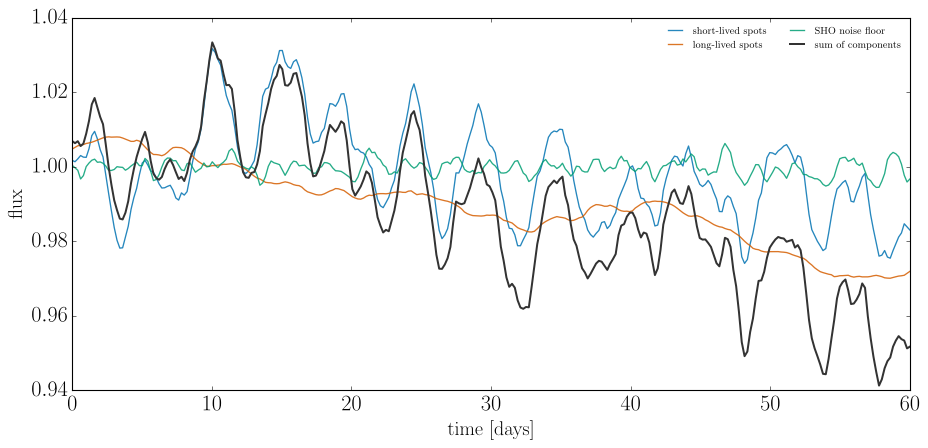

In [8]:
N = 300
x = np.linspace(0.0, 60.0, N)

component_samples = [term.sample(term.theta0, x, seed=seed)
                     for seed, term in enumerate(kernel.terms)]

y_signal = sum(component_samples)
y = 1.0 + y_signal + yerr_val * rng.standard_normal(N)

fig, ax = plt.subplots(figsize=(12, 6))
for y_i, c, lab in zip(component_samples, COMPONENT_COLORS, COMPONENT_LABELS):
    ax.plot(x, 1.0 + y_i, color=c, lw=1.2, alpha=0.85, label=lab)
ax.plot(x, 1.0 + y_signal, color=C_TOTAL, lw=1.8, label="sum of components")
ax.set_xlabel("time [days]")
ax.set_ylabel("flux")
ax.legend(frameon=False, fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

## 2. The kernel / ACF

Hand `kernel` to a `GPSolver` in place of a spot model — this is the same
sampled lightcurve from above, so the solver's kernel exactly matches what
generated it. `plot_acf(..., components=True)` calls `components()` once
and overlays every term against the empirical ACF, alongside the total.

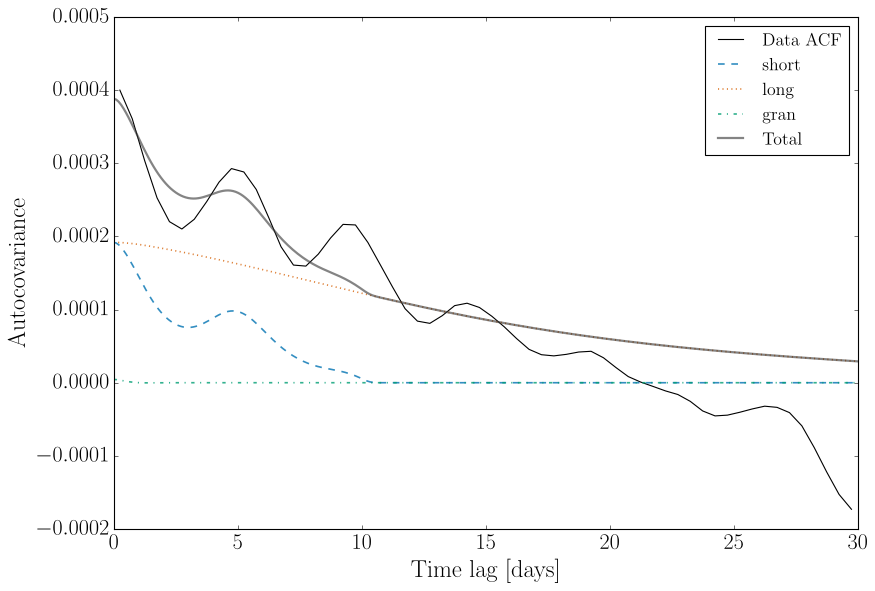

In [9]:
gp = GPSolver(x, y, yerr, kernel, matrix_solver="cholesky_full")
gp.build_jax()

fig, ax = plt.subplots(figsize=(12, 8))
gp.plot_acf(theta=gp.theta0, ax=ax, n_bins=60,
           components=True, component_colors=COMPONENT_COLORS,
           model_color=C_TOTAL, model_label="Total")
plt.show()

### Dropping the DC term

Real lightcurves are usually mean-subtracted or detrended before the ACF
is ever computed, which suppresses exactly the non-oscillating ($n=0$)
part of a spot term's kernel. `drop_dc=True` excludes that component from
every spot term (the SHO floor has no harmonic structure, so it is
unaffected) so the model curve is directly comparable to a
mean-subtracted empirical ACF:

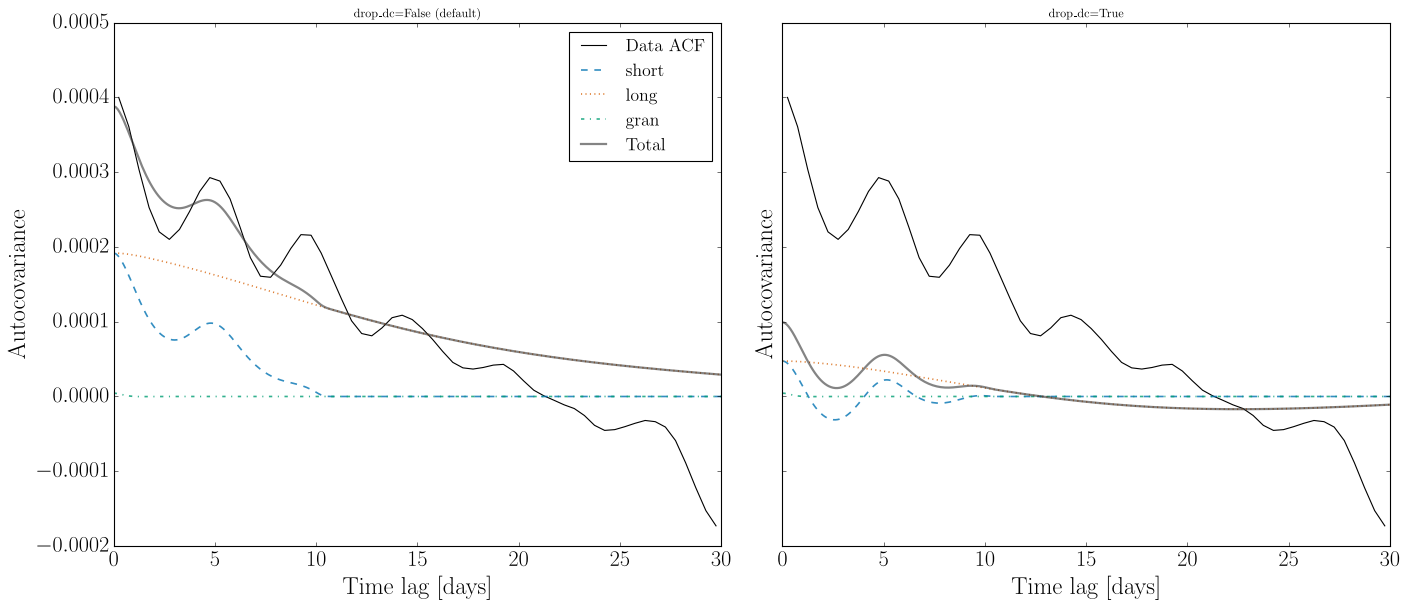

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
for ax, drop_dc, title in zip(axes, [False, True],
                              ["drop_dc=False (default)", "drop_dc=True"]):
    gp.plot_acf(theta=gp.theta0, ax=ax, n_bins=60,
               components=True, drop_dc=drop_dc,
               component_colors=COMPONENT_COLORS, model_color=C_TOTAL,
               model_label="Total", show_legend=(ax is axes[0]))
    ax.set_title(title, fontsize=11)
fig.tight_layout()
plt.show()

## 3. The PSD

Same idea, same `components=True` flag, this time for `plot_psd`. All
curves share one normalization (from the total's integral), so the
*relative* amplitudes between terms stay meaningful.

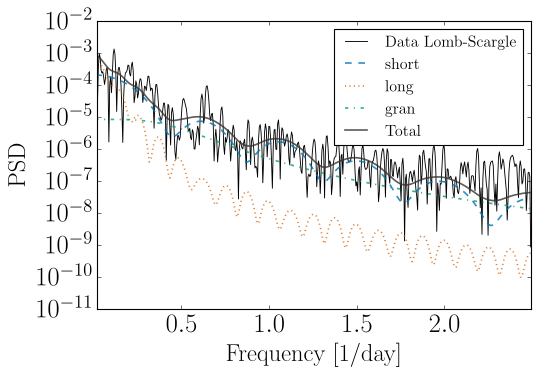

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
gp.plot_psd(theta=gp.theta0, ax=ax,
           components=True, component_colors=COMPONENT_COLORS,
           model_color=C_TOTAL, model_label="Total")
plt.show()

## Bonus: predicting a composite kernel at an arbitrary theta

`update_hparam` — and therefore `plot_prediction`'s `theta=` argument —
raises for a solver built from more than one term, since there is no
generic way to route a flat theta vector back into heterogeneous
component models:

In [7]:
try:
    gp.update_hparam({"short.peq": 10.5})
except NotImplementedError as exc:
    print("update_hparam:", exc)

update_hparam: update_hparam is not supported for a solver built from a composite kernel; update the term models and construct a new GPSolver instead.


`predict_at` needs no such round-trip — it evaluates
`kernel_sum.k_of_lag` directly from the theta you give it, doing its own
self-contained Cholesky solve. This is what you want after fitting, to
predict at a posterior sample or the posterior median from MCMC/nested
sampling:

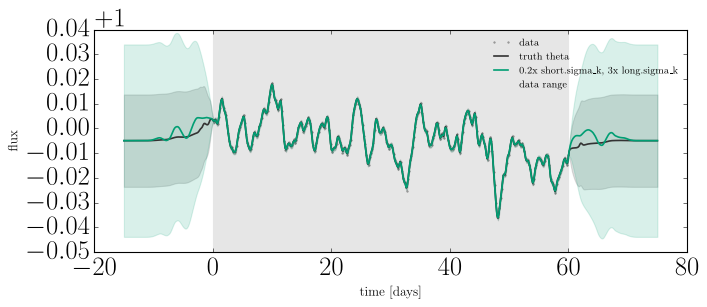

In [8]:
# Extend past the data edges: the mean reverts toward the baseline and the
# credible band widens there, which is where two thetas' predictions
# actually diverge visibly (interior to dense data, both are pulled to
# the observations regardless of theta).
xpred = np.linspace(x.min() - 15, x.max() + 15, 600)

theta_alt = np.array(gp.theta0, dtype=float)
i_short, i_long = (list(gp.param_keys).index(k)
                   for k in ("short.sigma_k", "long.sigma_k"))
theta_alt[i_short] *= 0.2
theta_alt[i_long] *= 3.0  # stand-in for "a posterior sample favoring the long-lived population"

mu_truth, var_truth = gp.predict_at(gp.theta0, xpred)
mu_alt, var_alt = gp.predict_at(theta_alt, xpred)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, ".", color="0.6", ms=3, label="data", zorder=0)
for mu, var, c, lab in [(mu_truth, var_truth, C_TOTAL, "truth theta"),
                        (mu_alt, var_alt, C_SHO,
                         "0.2x short.sigma_k, 3x long.sigma_k")]:
    sig = np.sqrt(np.maximum(var, 0.0))
    ax.plot(xpred, mu, color=c, lw=1.5, label=lab)
    ax.fill_between(xpred, mu - 2 * sig, mu + 2 * sig, color=c, alpha=0.15)
ax.axvspan(x.min(), x.max(), color="0.9", zorder=-1, label="data range")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_xlabel("time [days]")
ax.set_ylabel("flux")
fig.tight_layout()
plt.show()

## Summary

| Task | Method |
|---|---|
| Sample a single term's own process | `Term.sample(theta_slice, x, seed=...)` |
| Per-term covariance directly | `KernelSum.components(theta, lag_matrix.ravel())`, reshaped |
| Per-term ACF overlay | `GPSolver.plot_acf(theta=..., components=True)` |
| Per-term PSD overlay | `GPSolver.plot_psd(theta=..., components=True)` |
| Exclude the DC / $n=0$ term | `drop_dc=True` on either of the above, or `Term.k_of_lag_no_dc` directly |
| Predict at an arbitrary theta (composite-safe) | `GPSolver.predict_at(theta, xpred)` |

See [Composite Kernels](composite_kernels.ipynb) for how to build these
kernels in the first place, and [BlackJAX sampling](blackjax_sampling.ipynb)
/ [dynesty sampling](dynesty_sampling.ipynb) for turning MCMC/nested-sampling
output into the `theta` these methods expect.